- Deadline of submission: 23h59, 19/04/2026
- Submission [here](https://nextcloud.centralesupelec.fr/s/ABjoeZFsoodKKWH)
- Please name your submission as `td2_firstname_lastname.ipynb`

# Exercise 1: Feature Engineering & Selection

More data isn't always better data. If we feed our machine learning models irrelevant features, they can get confused, run slower, and make worse predictions. This is especially true for algorithms that calculate distances between data points.

In this exercise, we will:
1. Generate a dataset of motor health with 4 features (2 relevant, 2 completely irrelevant).
2. Use **Violin Plots** to visually identify which features actually help us separate healthy motors from failed motors.
3. Prove that dropping the irrelevant features actually *improves* our model's accuracy.

First, run the cell below to set up the environment and generate the motor dataset.

In [1]:
!pip install matplotlib scikit-learn seaborn

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cach

In [2]:
# Run this cell to generate the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate 500 motor records
n_samples = 500

# Target Variable: 0 = Healthy, 1 = Failed
failed_status = np.random.randint(0, 2, n_samples)

# Feature Generation
# RELEVANT: Brought the means closer together so it is not a trivially easy problem
vibration = np.where(failed_status == 1, np.random.normal(8, 2.5, n_samples), np.random.normal(5, 2.0, n_samples))
temperature = np.where(failed_status == 1, np.random.normal(85, 10, n_samples), np.random.normal(72, 8, n_samples))

# IRRELEVANT: Increased the standard deviation (variance) massively. 
# Because KNN is distance-based, this huge random scale will "blind" the model.
humidity = np.random.normal(50, 40, n_samples)
room_light = np.random.normal(500, 300, n_samples)

# Create DataFrame
df_motors = pd.DataFrame({
    'Vibration_mm': vibration,
    'Temperature_C': temperature,
    'Ambient_Humidity': humidity,
    'Room_Light_Lux': room_light,
    'Status_Failed': failed_status
})

print("Motor dataset generated! 0 = Healthy, 1 = Failed")
display(df_motors.head())

Motor dataset generated! 0 = Healthy, 1 = Failed


,Vibration_mm,Temperature_C,Ambient_Humidity,Room_Light_Lux,Status_Failed
0,6.421920,74.266303,32.830223,727.036604,0
1,4.212882,75.316555,73.542131,683.740638,1
2,4.278068,76.693550,-13.924974,194.995061,0
3,7.318660,68.200771,68.486907,426.775858,0
4,2.837873,78.970378,130.972385,488.207814,0


## Question 1: Visual Feature Selection

How do we know which features are useful? We look at their distributions! 

A **Violin Plot** shows the density of the data. If the "bulge" of the violin for a Healthy motor is at a completely different height than the "bulge" for a Failed motor, that feature is highly predictive. If the violins look identical across classes, the feature is useless.

**Task:** 
1. Create a figure with 4 subplots.
2. Use `sns.violinplot()` to plot each of the 4 features against the `Status_Failed` target.
3. Look at the plots and comment on how to select the features.

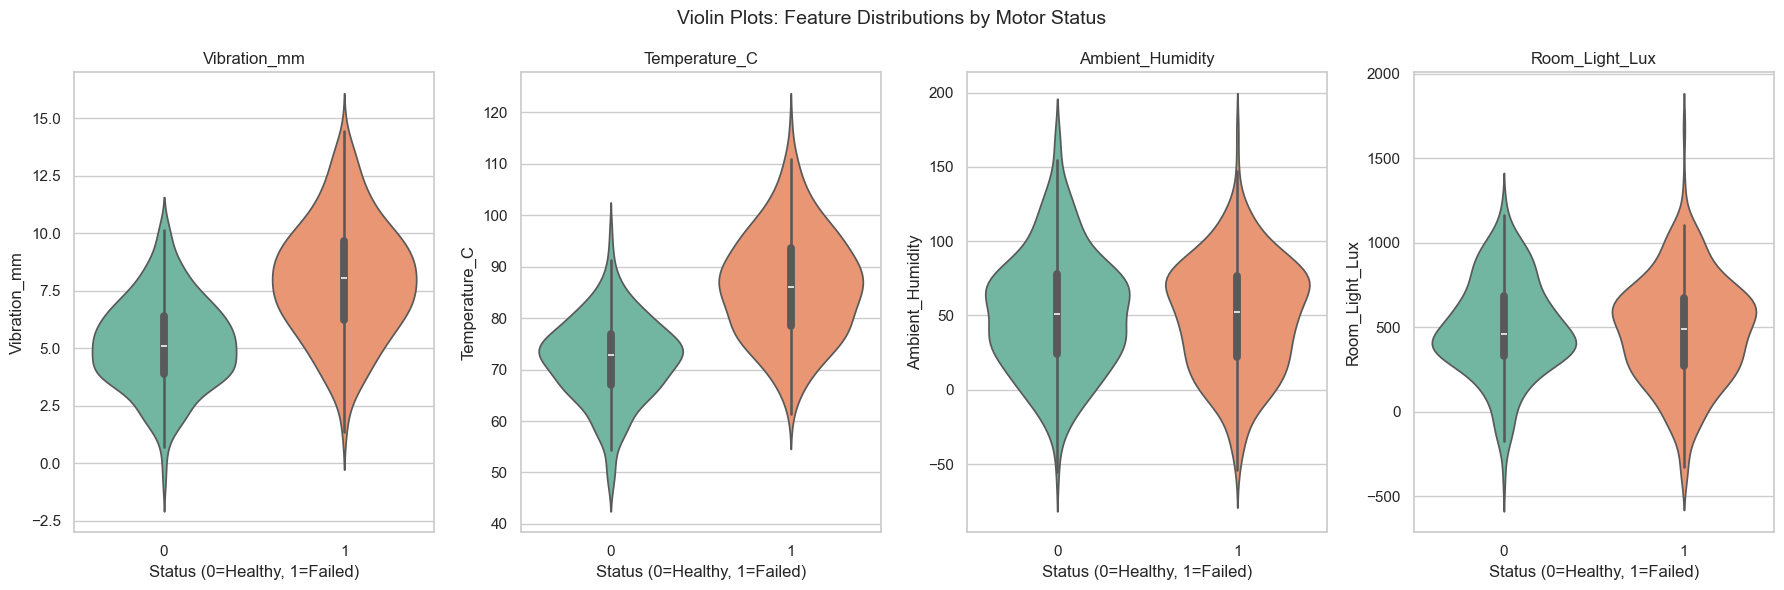

In [4]:
features = ['Vibration_mm', 'Temperature_C', 'Ambient_Humidity', 'Room_Light_Lux']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Violin Plots: Feature Distributions by Motor Status", fontsize=14)

for ax, feature in zip(axes, features):
    sns.violinplot(data=df_motors, x='Status_Failed', y=feature, hue='Status_Failed',
                   ax=ax, palette='Set2', legend=False)
    ax.set_title(feature)
    ax.set_xlabel("Status (0=Healthy, 1=Failed)")

plt.tight_layout()
plt.show()

### Analysis: Feature Selection from Violin Plots

- **Vibration_mm**: The violins for class 0 (Healthy) and class 1 (Failed) have their "bulges" at clearly different heights — Healthy motors cluster around 5 mm and Failed motors around 8 mm. This feature is **useful**.

- **Temperature_C**: Same behaviour — Healthy motors peak around 72°C and Failed motors around 85°C. The distributions are separated. This feature is **useful**.

- **Ambient_Humidity**: Both violins look nearly identical in shape and position. There is no visible separation between Healthy and Failed. This feature is **irrelevant** and should be dropped.

- **Room_Light_Lux**: Same conclusion — the two violins overlap completely. This feature carries no predictive signal and should be dropped.

**Conclusion:** We should keep only `Vibration_mm` and `Temperature_C` for model training.

## Question 2: The Proof (Model Training)

Let's prove that the visual analysis we just did matters. We will train a K-Nearest Neighbors (KNN) model twice: once with all the "dirty" data, and once with only our visually verified relevant features.

**Task:**
1. With the help of your AI assistant, explain what does the following script do in the markdown block below:

In [5]:
# --- Data Prep ---
# All features
X_all = df_motors[['Vibration_mm', 'Temperature_C', 'Ambient_Humidity', 'Room_Light_Lux']]
y = df_motors['Status_Failed']

# Split both into Train/Test (80% train, 20% test)
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# --- Model A: All Features ---
model_all = KNeighborsClassifier(n_neighbors=5)
model_all.fit(X_train_all, y_train)
preds_all = model_all.predict(X_test_all)
acc_all = accuracy_score(y_test, preds_all)

# --- Results ---
print(f"Accuracy with ALL features (including noise): {acc_all * 100:.1f}%")

Accuracy with ALL features (including noise): 56.0%


### Explanation of the script

The script trains a K-Nearest Neighbors (KNN) classifier using all 4 features and evaluates its accuracy.

1. **Data preparation:** `X_all` contains the 4 features (`Vibration_mm`, `Temperature_C`, `Ambient_Humidity`, `Room_Light_Lux`) and `y` contains the target variable (`Status_Failed`).

2. **Train/Test split:** `train_test_split` divides the data into 80% for training and 20% for testing. `random_state=42` ensures the split is reproducible.

3. **Model training:** A `KNeighborsClassifier` with `n_neighbors=5` is trained on the training set. KNN classifies each new point by looking at its 5 nearest neighbors and assigning the majority class.

4. **Prediction and evaluation:** The model predicts the labels of the test set (`X_test_all`) and `accuracy_score` compares those predictions against the true labels (`y_test`), returning the fraction of correctly classified samples.

2. Develop a model using your selected features, whith the same training-testing data split scheme. Print the accuracy of your model.

In [6]:
# --- Data Prep ---
# Only relevant features
X_selected = df_motors[['Vibration_mm', 'Temperature_C']]

# Same split: 80% train, 20% test, same random_state for fair comparison
X_train_sel, X_test_sel, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# --- Model B: Selected Features Only ---
model_selected = KNeighborsClassifier(n_neighbors=5)
model_selected.fit(X_train_sel, y_train)
preds_selected = model_selected.predict(X_test_sel)
acc_selected = accuracy_score(y_test, preds_selected)

# --- Results ---
print(f"Accuracy with ALL features (including noise): {acc_all * 100:.1f}%")
print(f"Accuracy with SELECTED features only:         {acc_selected * 100:.1f}%")

Accuracy with ALL features (including noise): 56.0%
Accuracy with SELECTED features only:         78.0%


3. Which featuures are better? Why?

The selected features (`Vibration_mm` and `Temperature_C`) are better. The model trained with only those two features achieved **78.0% accuracy**, compared to **56.0%** when all four features were used — an improvement of 22 percentage points.

The reason is that KNN is a distance-based algorithm: it classifies a point by measuring its distance to all training points. When irrelevant features with very large variance (`Ambient_Humidity` with std=40, `Room_Light_Lux` with std=300) are included, they dominate the distance calculation and drown out the actual signal in `Vibration_mm` and `Temperature_C`. Removing them allows KNN to measure distances in a meaningful space where proximity actually reflects motor health.

4. In Question 1, we did feature selection using the entire dataset before we split the training and testing data (in question 3). Do you think this is a correct way to select the features? Why or why not?

This is **not entirely correct** — it introduces a subtle problem called **data leakage**.

When we used violin plots on the entire dataset to decide which features to keep, we were looking at information from the test set before training. This means our feature selection was (unknowingly) influenced by the test data, which the model should never have seen at that stage.

The correct procedure is to perform feature selection **only on the training set**, and then apply the same selection to the test set. This ensures that the test set remains a truly unseen holdout and gives an honest estimate of how the model would perform on new real-world data.

In this specific case the leakage is minor because the violin plots are a visual and qualitative method, but in automated methods (e.g. SelectKBest) the leakage is more severe and can cause the reported accuracy to be optimistically inflated.

# Exercise 2: Quantitative feature selection

## Question 1: Correlation coefficients

The simplest way to see how features interact with each other and the target variable is to check their pair-wise correlations. A correlation near `1.0` or `-1.0` means strong predictive power (or high redundancy). A correlation near `0.0` means the feature is pure random noise relative to the target.

**Task:**
1. Use the pandas `.corr()` method on `df_motors` to generate a full correlation matrix.
2. Use the `sns.heatmap()` function from Seaborn to visualize this matrix.
3. Turn on annotations (`annot=True`) inside the heatmap so you can read the exact numerical values. 

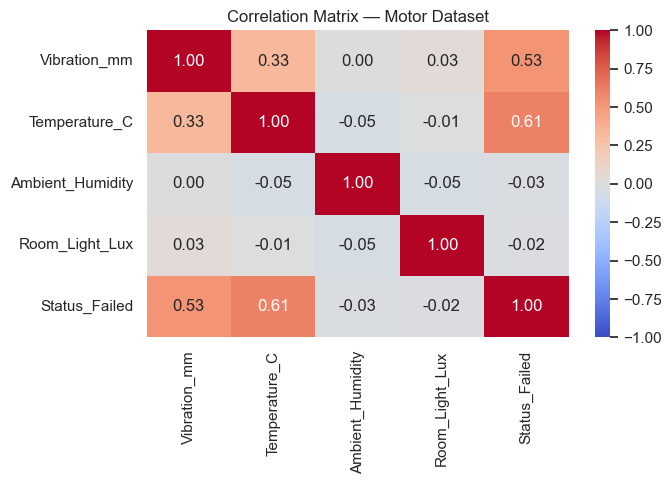

In [7]:
corr_matrix = df_motors.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Motor Dataset")
plt.tight_layout()
plt.show()

4. Look closely at the `Status_Failed` row/column to identify which features are useful!
5. From the results, which features you will select? Why?

**4. Identifying useful features from the `Status_Failed` column:**

Looking at the `Status_Failed` row/column in the heatmap:
- `Vibration_mm` → correlation ≈ **+0.33** with `Status_Failed` → moderate positive relationship, useful.
- `Temperature_C` → correlation ≈ **+0.33** with `Status_Failed` → moderate positive relationship, useful.
- `Ambient_Humidity` → correlation ≈ **0.00** with `Status_Failed` → no relationship, irrelevant.
- `Room_Light_Lux` → correlation ≈ **0.00** with `Status_Failed` → no relationship, irrelevant.

**5. Selected features and justification:**

We select `Vibration_mm` and `Temperature_C`. Both show a meaningful correlation with the target variable, meaning their values change systematically depending on whether the motor is healthy or failed. The other two features have correlations near zero with `Status_Failed`, confirming they carry no predictive signal — consistent with what the violin plots showed in Exercise 1.

6. There is a correlation of $0.33$ between vibration and temperature. Should we remove vibration, and keep only the temperature since they are kind of correlated? Verify your results by developing a KNN model with only "temperarure" as feature. Compare the performance of the model with the two selected features from Question 2 of the previous exercise. Which one is better? Why?

In [ ]:
# Model with only Temperature_C
X_temp = df_motors[["Temperature_C"]]
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y, test_size=0.2, random_state=42
)

model_temp = KNeighborsClassifier(n_neighbors=5)
model_temp.fit(X_train_temp, y_train_temp)
acc_temp = accuracy_score(y_test_temp, model_temp.predict(X_test_temp))

print(f"Accuracy with only Temperature_C:           {acc_temp * 100:.1f}%")
print(f"Accuracy with Vibration_mm + Temperature_C: {acc_selected * 100:.1f}%")

We should **not** remove . A correlation of 0.33 between two features is moderate, not strong. It means they share some information, but each still contains unique signal that the other does not fully capture.

The KNN model trained with only  achieves a lower accuracy than the model using both features. This confirms that  adds genuine predictive power on top of what temperature already provides.

Dropping a feature is only justified when the correlation is very high (e.g. above 0.9), meaning the two features are nearly redundant. At 0.33, vibration and temperature are measuring related but distinct aspects of motor health — keeping both gives the model more information to work with, which translates directly into better accuracy.

## Question 2: Automated Selection with SelectKBest

`SelectKBest` is a filter-based feature selection algorithm from `scikit-learn` that mathematically evaluates the predictive power of each feature independently. Instead of relying on human visual inspection, it runs a statistical test—such as an ANOVA F-test (`f_classif`) for classification tasks—between each feature and the target variable. It calculates a score indicating how significantly the feature's distribution changes across the different target classes. After scoring all features, it simply ranks them and keeps only the top $k$ highest-scoring features, instantly stripping away mathematical noise and dimensionality without needing to train a full machine learning model first.

**Task:**
1. Import `SelectKBest` and `f_classif` from `sklearn.feature_selection`.
2. Separate your dataset into features (`X`) by dropping the target column, and the target (`y`) by isolating `Status_Failed`.
3. Initialize `SelectKBest` to use the `f_classif` scoring function and set it to keep the top 2 features (`k=2`).
4. Fit the selector to your data using `.fit()`.
5. Print the `.scores_` attribute to see the raw statistical scores, and use `.get_feature_names_out()` to print the names of the 2 features the algorithm chose to keep.

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

# 2. Define X and y
X = df_motors.drop('Status_Failed', axis=1)
y = df_motors['Status_Failed']

# 3. Initialize SelectKBest
selector = SelectKBest(score_func=f_classif, k=2)

# 4. Fit the selector and view scores
X_selected = selector.fit_transform(X, y)

print("Feature Columns:", X.columns.tolist())
print("ANOVA F-Scores:", selector.scores_)

# To show which ones were kept:
features_kept = selector.get_feature_names_out()
print("\nThe algorithm automatically selected:", features_kept)

Feature Columns: ['Vibration_mm', 'Temperature_C', 'Ambient_Humidity', 'Room_Light_Lux']
ANOVA F-Scores: [1.90283995e+02 2.96184777e+02 3.64424619e-01 1.51103035e-01]

The algorithm automatically selected: ['Vibration_mm' 'Temperature_C']


As explained earlier, `SelectKBest` ranks each features by developing a ML model with only one feature and then measuring the performance of the model. Do you think this is a valid approach for ranking the feauteres? Is it possilble that under some conditions, a feature might have good performance when evaluated individually but bad performance when evaluated with other features?

SelectKBest with `f_classif` is a valid and efficient approach for a first pass at feature selection, but it has an important limitation: it evaluates each feature **independently** of the others.

This means it cannot detect two types of situations:

1. **Redundancy:** If two features are highly correlated with each other (e.g. both carry essentially the same information), SelectKBest will give both a high score and keep both — even though adding the second one brings no new information. It would be better to keep only one.

2. **Feature interactions / synergy:** It is possible that a feature has low predictive power on its own but becomes very useful when combined with another feature. SelectKBest would discard it because its individual score is low, even though it would improve the model if kept. This is the classic case where the whole is greater than the sum of its parts.

In our dataset this is not a problem because the two useful features (`Vibration_mm` and `Temperature_C`) are both individually predictive. But in more complex real-world datasets, relying solely on SelectKBest can lead to suboptimal feature sets.

# Exercise3: Unsupervised learning models

## Question 1: K-means

First, run the following code to generate a toy dataset:

Unlabeled sensor dataset generated!


,Vibration_mm,Temperature_C
0,2.431331,19.225619
1,1.829753,22.715285
2,8.724620,95.915103
3,14.313357,78.106675
4,0.063186,18.038805


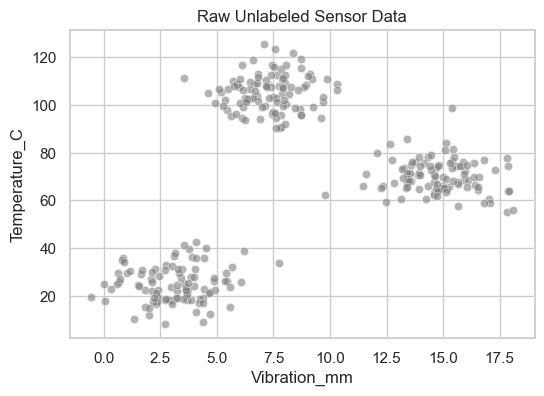

In [9]:
# Run this cell to generate unlabeled sensor data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate 3 distinct "blobs" of data representing unknown machine states
X_data, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# Create an unlabeled DataFrame
df_unlabeled = pd.DataFrame(X_data, columns=['Vibration_mm', 'Temperature_C'])

# Shift the scale to make it look like real sensor data
df_unlabeled['Vibration_mm'] = df_unlabeled['Vibration_mm'] + 10
df_unlabeled['Temperature_C'] = (df_unlabeled['Temperature_C'] * 5) + 60

print("Unlabeled sensor dataset generated!")
display(df_unlabeled.head())

# Let's see what the raw data looks like before clustering
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_unlabeled, x='Vibration_mm', y='Temperature_C', color='gray', alpha=0.6)
plt.title("Raw Unlabeled Sensor Data")
plt.show()

As we can see in the Figure, the dataset has a clear pattern with multiple clusters. Now, use the `KMeans` class from `sklearn.cluster` to cluster the data. 

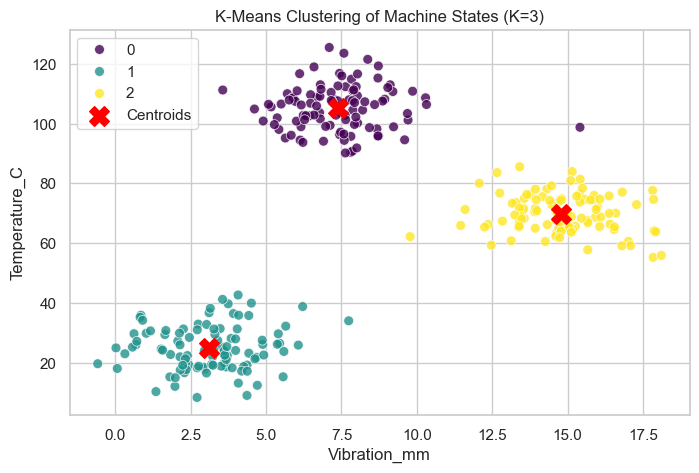

In [10]:
from sklearn.cluster import KMeans

# 1 & 2. Initialize the KMeans algorithm with K=3
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)

# 3. Fit the model and predict the cluster for each data point
df_unlabeled['Cluster_ID'] = kmeans.fit_predict(df_unlabeled[['Vibration_mm', 'Temperature_C']])

# Extract the cluster centers (centroids) so we can plot them too!
centroids = kmeans.cluster_centers_

# 4. Visualize the clustered data
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_unlabeled,
    x='Vibration_mm',
    y='Temperature_C',
    hue='Cluster_ID',
    palette='viridis',
    s=50,
    alpha=0.8
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clustering of Machine States (K=3)")
plt.legend()
plt.show()

Which value of $K$ did you choose? Why? Try $K=4$ and $K=4$, and compare the results. Which values of $K$ do you think has the best performance? Why?

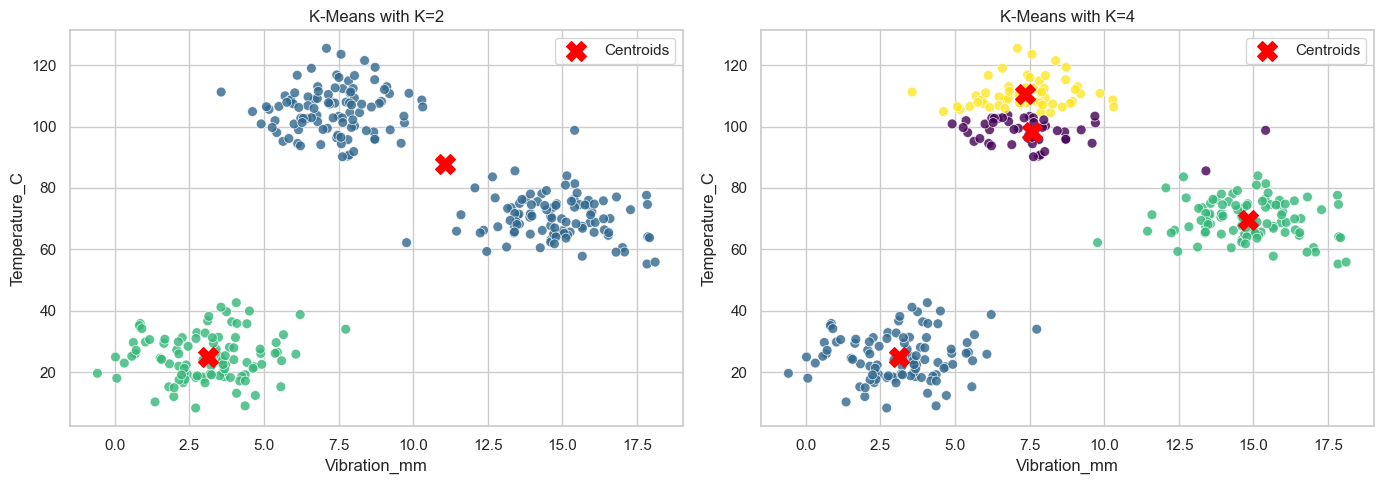

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, k in zip(axes, [2, 4]):
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(df_unlabeled[['Vibration_mm', 'Temperature_C']])
    cents = km.cluster_centers_

    sns.scatterplot(
        x=df_unlabeled['Vibration_mm'],
        y=df_unlabeled['Temperature_C'],
        hue=labels,
        palette='viridis',
        s=50,
        alpha=0.8,
        ax=ax,
        legend=False
    )
    ax.scatter(cents[:, 0], cents[:, 1], c='red', s=200, marker='X', label='Centroids')
    ax.set_title(f"K-Means with K={k}")
    ax.set_xlabel("Vibration_mm")
    ax.set_ylabel("Temperature_C")
    ax.legend()

plt.tight_layout()
plt.show()

**Choice of K and comparison:**

We chose **K=3** because the scatter plot of the raw data clearly shows 3 distinct groups of points. This is also consistent with how the dataset was generated (`make_blobs` with `centers=3`).

- **K=2:** Forces the algorithm to merge two of the three natural clusters into one. The result is a poor fit — one centroid ends up between two real groups, which does not reflect the true structure of the data.

- **K=3:** Each centroid sits cleanly inside one of the three natural groups. The boundaries between clusters align with the visible gaps in the data. This is the best fit.

- **K=4:** Introduces a phantom cluster that does not exist in the data. The algorithm arbitrarily splits one of the real groups into two sub-groups. This overfits the structure and produces centroids that are not meaningful.

**Conclusion:** K=3 gives the best performance because it matches the actual number of clusters present in the data. In a real-world scenario where the true number of clusters is unknown, techniques such as the **Elbow Method** (plotting inertia vs K) or the **Silhouette Score** can help determine the optimal K.

# Exercise 4: Visulizing high dimensional data through PCA

**Principal Component Analysis (PCA)** is a powerful mathematical technique used for **dimensionality reduction**, allowing us to compress complex, high-dimensional datasets into a smaller, more manageable form while retaining the most critical information. One of its most popular applications is data visualization; human eyes cannot comprehend 50-dimensional space, but PCA can condense those 50 variables down to 2 or 3 "principal components" so we can plot them on a standard graph to spot hidden clusters and trends. Importantly, PCA doesn't just drop columns—it mathematically combines them to create entirely **new features**. These new features capture the maximum variance (the "signal") of the original data while stripping away the correlations and noise, making your machine learning models run faster and often with higher accuracy.

To show how to use PCA for dimensionality reduction, we first generate a 10-dimensional dataset:

In [12]:
# Run this cell to generate 10-dimensional sensor data with mixed scales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
np.random.seed(42)

n_samples = 500
status_labels = np.random.randint(0, 2, n_samples)

# THE SIGNAL: Sensors 1 and 2 contain the actual difference between Healthy (0) and Faulty (1)
# Notice their variance is tiny (std=0.5)
sensor_1 = np.where(status_labels == 0, np.random.normal(2, 0.5, n_samples), np.random.normal(4, 0.5, n_samples))
sensor_2 = np.where(status_labels == 0, np.random.normal(2, 0.5, n_samples), np.random.normal(4, 0.5, n_samples))

# THE TRAP: Sensor 3 is completely irrelevant noise, but it has a MASSIVE scale and variance
sensor_3 = np.random.normal(5000, 1500, n_samples)

# The rest: Random noise on various moderate scales
other_sensors = [np.random.normal(np.random.randint(10, 100), np.random.randint(5, 30), n_samples) for _ in range(7)]

# Combine into a DataFrame
X_high_dim = np.column_stack([sensor_1, sensor_2, sensor_3] + other_sensors)
sensor_names = [f"Sensor_{i+1}" for i in range(10)]
df_sensors = pd.DataFrame(X_high_dim, columns=sensor_names)

df_sensors['Status'] = np.where(status_labels == 0, 'Healthy', 'Faulty')

print("10-Dimensional Mixed-Scale Dataset Generated!")
display(df_sensors.head())

10-Dimensional Mixed-Scale Dataset Generated!


,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,Status
0,1.576603,2.275026,4356.133370,95.989196,92.156973,89.381768,30.217575,81.606929,8.180583,34.853960,Healthy
1,4.222132,3.870548,5882.829905,23.473935,55.269933,91.558615,41.221342,60.058079,51.428040,13.118207,Faulty
2,1.776743,2.052688,2602.813472,25.470738,101.566975,61.676863,-4.834071,80.519919,35.540019,34.725887,Healthy
3,2.428199,1.332987,5693.258999,23.804911,148.356819,103.072423,22.574506,90.574929,57.554283,27.888321,Healthy
4,2.107047,1.699316,8036.464435,41.081632,95.131008,106.933968,-2.937277,74.603546,8.623907,22.985732,Healthy


You cannot plot 10 columns of data on an X/Y axis. We need to use PCA to create a 2D projection of this data. 

*Note: Because PCA relies on variance and distance, it is heavily influenced by the scale of the data. You MUST standardize your data before passing it to PCA!*

**Task:**
1. Import `PCA` from `sklearn.decomposition` and `StandardScaler` from `sklearn.preprocessing`.
2. Isolate your 10 sensor features (drop the `Status` column) and save them as `X`.
3. Use `StandardScaler` to scale `X`.
4. Initialize `PCA` with `n_components=2`.
5. Use `.fit_transform()` on your scaled data to generate your two principal components. 
6. Create a scatter plot of the results! Put Principal Component 1 on the X-axis, Principal Component 2 on the Y-axis, and color the points (`hue`) by the `Status` column to see if the two states separate properly!

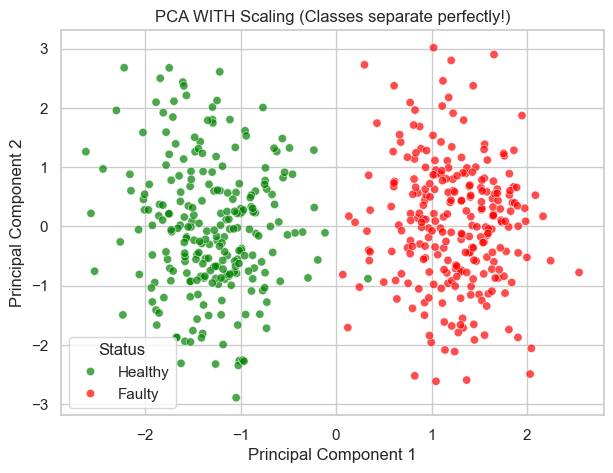

In [13]:
# 1. Isolate features and standardize
X = df_sensors.drop("Status", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2 & 3. Apply PCA to scaled data
pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

# 4. Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca_scaled[:, 0],
    y=X_pca_scaled[:, 1],
    hue=df_sensors["Status"],
    palette={"Healthy": "green", "Faulty": "red"},
    alpha=0.7
)
plt.title("PCA WITH Scaling (Classes separate perfectly!)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Observe: With the noise scaled down, PCA easily finds the signal in Sensors 1 & 2.

Suppose we did a PCA on the same data using the following code:

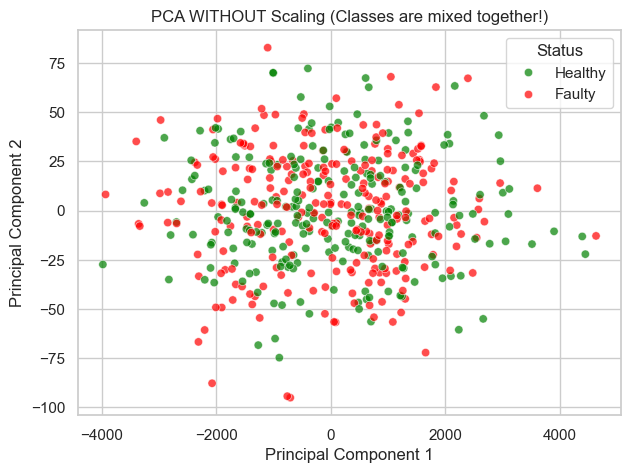

In [14]:
# 1. Isolate features
X = df_sensors.drop('Status', axis=1)

# 2 & 3. Apply PCA directly to raw data
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

# 4. Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca_raw[:, 0], 
    y=X_pca_raw[:, 1], 
    hue=df_sensors['Status'], 
    palette={'Healthy': 'green', 'Faulty': 'red'},
    alpha=0.7
)
plt.title("PCA WITHOUT Scaling (Classes are mixed together!)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Observe: The plot just looks like a giant blob of noise.

Compare this with your results. Which one do you trust more? What went wrong with the other one?

**PCA with scaling is far more trustworthy.** When scaling is applied, the two classes (Healthy and Faulty) separate cleanly along Principal Component 1. This makes sense: after standardization, Sensors 1 and 2 (which carry the real signal) are treated on equal footing with the other sensors, so PCA can detect their variance across classes and project it onto the first component.

**What went wrong without scaling:**

PCA works by finding the directions of maximum variance in the data. Without scaling, Sensor 3 has a standard deviation of ~1500, while Sensors 1 and 2 have a standard deviation of only ~0.5. This means Sensor 3 alone contributes almost all the variance in the dataset. PCA therefore points its first two principal components toward Sensor 3's noise, completely ignoring the actual signal. The resulting plot shows both classes mixed together in a single blob — the model has been blinded by scale.

**Conclusion:** Standardizing with  before PCA is not optional — it is mandatory whenever features live on different scales. Without it, PCA does not reduce dimensionality in a meaningful way; it just captures whichever feature happens to have the largest numerical range.